<a href="https://colab.research.google.com/github/JairusTheAnalyst/JairusTheAnalyst/blob/main/RF_on_Breast_Cancer_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve

In [38]:
breast_cancer=load_breast_cancer()
breast_cancer=pd.DataFrame(breast_cancer.data,columns=breast_cancer.feature_names)

In [39]:
breast_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [13]:
X=breast_cancer.data
y=breast_cancer.target


In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
Scaler=StandardScaler()
X_train=Scaler.fit_transform(X_train)
X_test=Scaler.transform(X_test)

In [20]:
RF_model=RandomForestClassifier()
RF_model.fit(X_train,y_train)

RandomForestClassifier()

In [29]:
RF_model_pred=RF_model.predict(X_test)
print(accuracy_score(y_test,RF_model_pred))
print(classification_report(y_test,RF_model_pred))
print(confusion_matrix(y_test,RF_model_pred))
print(roc_curve(y_test,RF_model_pred))

0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[[40  3]
 [ 1 70]]
(array([0.        , 0.06976744, 1.        ]), array([0.        , 0.98591549, 1.        ]), array([inf,  1.,  0.]))


In [31]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.98204467 0.01617649]


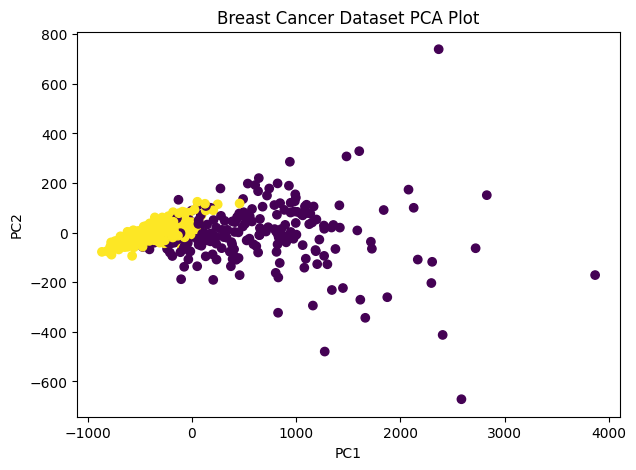

In [34]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Breast Cancer Dataset PCA Plot")
plt.show()


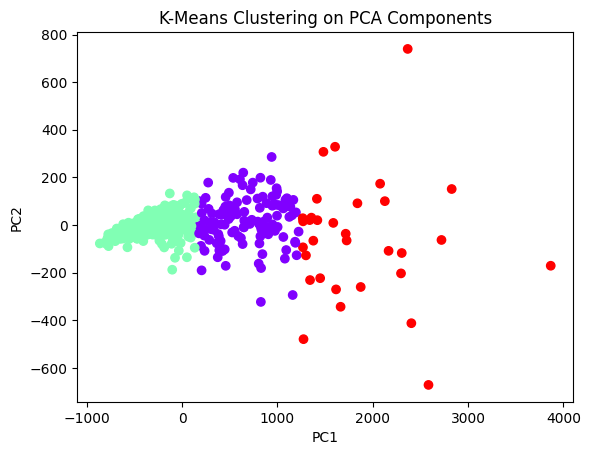

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='rainbow')
plt.title("K-Means Clustering on PCA Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
